In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import wasserstein_distance, ks_2samp, chi2_contingency, entropy, pointbiserialr
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import warnings
from sklearn.metrics import mean_squared_error

In [ ]:
def shorten_category(cat, max_len=15, ellipsis='...'):
    """Сокращает строку до max_len символов, добавляя ellipsis при необходимости."""
    if isinstance(cat, str) and len(cat) > max_len:
        return cat[:max_len - len(ellipsis)] + ellipsis
    return str(cat)

def test_onehot_fields(real_df, synth_df, fields, max_label_length=15, truncate_ellipsis='...'):
    """
    Тестирование полей, которые должны быть one-hot закодированы.
    Добавлено сокращение длинных названий категорий для графиков.
    """
    results = {}
    
    for field in fields:
        if field not in real_df.columns or field not in synth_df.columns:
            print(f"Field '{field}' not found in both datasets. Skipping.")
            continue
            
        print(f"\n{'='*60}")
        print(f"ANALYSIS FOR: {field}")
        print(f"{'='*60}")
        
        real_unique = real_df[field].nunique()
        synth_unique = synth_df[field].nunique()
        
        # Получаем распределения (нормализованные)
        real_counts = real_df[field].value_counts(normalize=True).head(10)
        synth_counts = synth_df[field].value_counts(normalize=True).head(10)
        
        real_categories = set(real_df[field].unique())
        synth_categories = set(synth_df[field].unique())
        coverage = len(real_categories & synth_categories) / max(1, len(real_categories)) * 100
        
        all_categories = sorted(list(real_categories | synth_categories))
        contingency = pd.DataFrame({
            'real': [real_df[field].value_counts().get(cat, 0) for cat in all_categories],
            'synth': [synth_df[field].value_counts().get(cat, 0) for cat in all_categories]
        })
        
        try:
            chi2_stat, chi2_p, dof, expected = chi2_contingency(contingency.values)
        except Exception as e:
            chi2_stat, chi2_p, dof, expected = None, None, None, None
            print(f"Chi-square test failed for {field}: {e}")
        
        real_entropy = entropy(real_df[field].value_counts(normalize=True))
        synth_entropy = entropy(synth_df[field].value_counts(normalize=True))
        
        results[field] = {
            'real_unique_count': real_unique,
            'synth_unique_count': synth_unique,
            'category_coverage_percent': coverage,
            'chi2_statistic': chi2_stat,
            'chi2_pvalue': chi2_p,
            'real_entropy': real_entropy,
            'synth_entropy': synth_entropy,
            'entropy_difference': abs(real_entropy - synth_entropy),
            'distribution_similar': chi2_p > 0.05 if chi2_p is not None else None
        }
        
        try:
            fig, axes = plt.subplots(1, 3, figsize=(18, 5))
            
            top_n = min(10, len(real_counts), len(synth_counts))
            
            if top_n > 0:
                x = np.arange(top_n)
                width = 0.35
                
                # Сокращаем метки для графика
                real_labels = [shorten_category(cat, max_label_length, truncate_ellipsis) for cat in real_counts.index[:top_n]]
                synth_values = [synth_counts.get(cat, 0) for cat in real_counts.index[:top_n]]
                
                axes[0].bar(x - width/2, real_counts.values[:top_n], width, 
                           label='Real', alpha=0.7, color='blue')
                axes[0].bar(x + width/2, synth_values, width, 
                           label='Synthetic', alpha=0.7, color='orange')
                axes[0].set_xticks(x)
                axes[0].set_xticklabels(real_labels, rotation=45, ha='right', fontsize=9)
                axes[0].set_title(f'Top {top_n} Categories: {field}')
                axes[0].legend()
                axes[0].set_ylabel('Proportion')
                axes[0].grid(True, alpha=0.2)
            else:
                axes[0].text(0.5, 0.5, 'No data', ha='center', va='center')
                axes[0].set_title(f'Top Categories: {field}')
            
            # Круговая диаграмма покрытия
            coverage_data = [
                len(real_categories - synth_categories),  # Только в реальных
                len(real_categories & synth_categories),  # В обоих
                len(synth_categories - real_categories)   # Только в синтетических
            ]
            if sum(coverage_data) > 0:
                labels = ['Only in Real', 'In Both', 'Only in Synthetic']
                colors = ['red', 'green', 'orange']
                wedges, texts, autotexts = axes[1].pie(
                    coverage_data, labels=labels, colors=colors, autopct='%1.1f%%',
                    startangle=90
                )
                axes[1].set_title(f'Category Coverage: {field}')
                # Уменьшаем размер текста внутри секторов
                for autotext in autotexts:
                    autotext.set_fontsize(9)
            else:
                axes[1].text(0.5, 0.5, 'No data', ha='center', va='center')
                axes[1].set_title(f'Category Coverage: {field}')
            
            # Сравнение энтропии
            axes[2].bar(['Real', 'Synthetic'], [real_entropy, synth_entropy], 
                       color=['blue', 'orange'], alpha=0.7, edgecolor='black')
            axes[2].set_title(f'Entropy Comparison: {field}')
            axes[2].set_ylabel('Entropy')
            axes[2].grid(True, alpha=0.3)
            axes[2].set_ylim(0, max(real_entropy, synth_entropy) * 1.1)
            
            plt.tight_layout()
            plt.show()
            
        except Exception as e:
            print(f"Visualization error for {field}: {e}")
        
        # --- Вывод результатов ---
        print(f"Unique values: Real={real_unique}, Synthetic={synth_unique}")
        print(f"Category coverage: {coverage:.1f}%")
        if chi2_p is not None:
            status = 'Similar' if chi2_p > 0.05 else 'Different'
            print(f"Chi-square test: p-value = {chi2_p:.4f} ({status})")
        else:
            print("Chi-square test: Not applicable (insufficient data)")
        print(f"Entropy: Real={real_entropy:.3f}, Synthetic={synth_entropy:.3f}")
        
        if len(real_counts) > 0:
            top_real_short = [shorten_category(cat, 20, '...') for cat in real_counts.index[:min(3, len(real_counts))]]
            print(f"Top 3 real categories: {top_real_short}")
        if len(synth_counts) > 0:
            top_synth_short = [shorten_category(cat, 20, '...') for cat in synth_counts.index[:min(3, len(synth_counts))]]
            print(f"Top 3 synth categories: {top_synth_short}")
    
    return results

In [42]:

# 2. ТЕСТЫ ДЛЯ ВЫСОКОКАРДИНАЛЬНЫХ КАТЕГОРИАЛЬНЫХ ПОЛЕЙ
def test_categorical_fields(real_df, synth_df, fields):
    """
    Тестирование полей с высокой кардинальностью (ACCOUNT_ID, TERMINAL_CODE и т.д.)
    """
    results = {}
    
    for field in fields:
        if field in real_df.columns and field in synth_df.columns:
            print(f"\n{'='*60}")
            print(f"HIGH CARDINALITY ANALYSIS: {field}")
            print(f"{'='*60}")
            
            # Статистики уникальности
            real_unique = real_df[field].nunique()
            synth_unique = synth_df[field].nunique()
            
            # Частота появления значений
            real_freq = real_df[field].value_counts()
            synth_freq = synth_df[field].value_counts()
            
            # Распределение частот появления
            real_freq_dist = real_freq.value_counts(normalize=True)
            synth_freq_dist = synth_freq.value_counts(normalize=True)
            
            # Проверка на повторяемость паттернов
            overlap = len(set(real_df[field]) & set(synth_df[field]))
            
            # Анализ новых значений
            new_in_synth = len(set(synth_df[field]) - set(real_df[field]))
            
            results[field] = {
                'real_unique_count': real_unique,
                'synth_unique_count': synth_unique,
                'overlap_count': overlap,
                'new_in_synth_count': new_in_synth,
                'overlap_percentage': overlap / max(1, real_unique) * 100,
                'new_percentage': new_in_synth / max(1, synth_unique) * 100,
                'real_mean_frequency': real_freq.mean() if len(real_freq) > 0 else 0,
                'synth_mean_frequency': synth_freq.mean() if len(synth_freq) > 0 else 0,
                'real_freq_entropy': entropy(real_freq_dist) if len(real_freq_dist) > 0 else 0,
                'synth_freq_entropy': entropy(synth_freq_dist) if len(synth_freq_dist) > 0 else 0
            }
            
            # Визуализация
            try:
                fig, axes = plt.subplots(2, 2, figsize=(15, 10))
                
                # Distribution of frequencies
                if len(real_freq) > 0 and len(synth_freq) > 0:
                    max_freq = min(50, max(real_freq.max(), synth_freq.max()))
                    bins = np.arange(0, max_freq + 1, max(1, max_freq//20))
                    
                    axes[0, 0].hist(real_freq.values, bins=bins, alpha=0.7, 
                                   label=f'Real (n={real_unique})', density=True)
                    axes[0, 0].hist(synth_freq.values, bins=bins, alpha=0.7, 
                                   label=f'Synth (n={synth_unique})', density=True)
                    axes[0, 0].set_xlabel('Frequency of occurrence')
                    axes[0, 0].set_ylabel('Density')
                    axes[0, 0].set_title(f'Frequency Distribution: {field}')
                    axes[0, 0].legend()
                    axes[0, 0].grid(True, alpha=0.3)
                else:
                    axes[0, 0].text(0.5, 0.5, 'No data', ha='center', va='center')
                    axes[0, 0].set_title(f'Frequency Distribution: {field}')
                
                # Top frequencies comparison
                top_n = min(20, len(real_freq), len(synth_freq))
                if top_n > 0:
                    real_top = real_freq.head(top_n)
                    synth_top = synth_freq.head(top_n)
                    
                    x = np.arange(top_n)
                    width = 0.35
                    
                    axes[0, 1].bar(x - width/2, real_top.values, width, label='Real', alpha=0.7)
                    axes[0, 1].bar(x + width/2, synth_top.values, width, label='Synthetic', alpha=0.7)
                    axes[0, 1].set_xlabel('Rank')
                    axes[0, 1].set_ylabel('Frequency')
                    axes[0, 1].set_title(f'Top {top_n} Most Frequent Values: {field}')
                    axes[0, 1].legend()
                    axes[0, 1].set_xticks(x)
                    axes[0, 1].set_xticklabels(range(1, top_n+1))
                else:
                    axes[0, 1].text(0.5, 0.5, 'No data', ha='center', va='center')
                    axes[0, 1].set_title(f'Top Frequencies: {field}')
                
                # Unique values analysis
                categories = ['Real Only', 'Both', 'Synthetic Only']
                counts = [real_unique - overlap, overlap, new_in_synth]
                colors = ['blue', 'green', 'orange']
                
                axes[1, 0].bar(categories, counts, color=colors, alpha=0.7)
                axes[1, 0].set_title(f'Unique Values Analysis: {field}')
                axes[1, 0].set_ylabel('Count')
                for i, (cat, count) in enumerate(zip(categories, counts)):
                    axes[1, 0].text(i, count + max(counts)*0.02, str(count), 
                                   ha='center', va='bottom')
                
                # Log-log plot for frequency distribution (Zipf's law)
                if len(real_freq) > 1 and len(synth_freq) > 1:
                    axes[1, 1].loglog(np.arange(1, len(real_freq)+1), real_freq.values, 
                                    'o-', alpha=0.7, label='Real', markersize=4)
                    axes[1, 1].loglog(np.arange(1, len(synth_freq)+1), synth_freq.values, 
                                    's-', alpha=0.7, label='Synthetic', markersize=4)
                    axes[1, 1].set_xlabel('Rank (log)')
                    axes[1, 1].set_ylabel('Frequency (log)')
                    axes[1, 1].set_title(f'Zipf Plot: {field}')
                    axes[1, 1].legend()
                    axes[1, 1].grid(True, alpha=0.3)
                else:
                    axes[1, 1].text(0.5, 0.5, 'Not enough data', ha='center', va='center')
                    axes[1, 1].set_title(f'Zipf Plot: {field}')
                
                plt.tight_layout()
                plt.show()
            except Exception as e:
                print(f"Visualization error for {field}: {e}")
            
            # Вывод результатов
            print(f"Unique values: Real={real_unique:,}, Synthetic={synth_unique:,}")
            print(f"Overlap: {overlap:,} values ({overlap/max(1, real_unique)*100:.1f}% of real)")
            print(f"New in synthetic: {new_in_synth:,} values ({new_in_synth/max(1, synth_unique)*100:.1f}% of synth)")
            print(f"Mean frequency: Real={results[field]['real_mean_frequency']:.2f}, "
                  f"Synthetic={results[field]['synth_mean_frequency']:.2f}")
            
            # Проверка на утечку данных
            if overlap > real_unique * 0.1:  # Если больше 10% пересечения
                print(f"⚠ WARNING: High overlap ({overlap/max(1, real_unique)*100:.1f}%) - possible data leakage!")
    
    return results


In [ ]:
ONEHOT_FIELDS = ['PaymentSystem', 'OpType', 'DETAILEDCARDTYPE', 'TRANMETHOD', 'ISOWNTERMINAL', 
                'NAME', 'MCC', 'DEVICETYPE', 'CurrencyName', 'CITY', 'REGION', 'ISVIRTUALTRANSACTION']
CATEGORICAL_FIELDS = ['ACCOUNT_ID', 'TERMINAL_CODE', 'CARD', 'TRANS_DETAIL']

real_data = pd.read_csv('Data/Sber/Clear/transact_compare.csv')  # Реальные данные
synth_data = pd.read_csv('Data/Sber/Clear/transact_400000_samples.csv')

In [62]:
from scipy.spatial.distance import jensenshannon
def compare_categorical(real, synth):
    real_p = real.value_counts(normalize=True)
    synth_p = synth.value_counts(normalize=True)
    
    all_cats = real_p.index.union(synth_p.index)
    real_p = real_p.reindex(all_cats, fill_value=0.0)
    synth_p = synth_p.reindex(all_cats, fill_value=0.0)
    
    jsd = jensenshannon(real_p, synth_p)
    coverage = len(set(real) & set(synth)) / len(set(real))
    ent_diff = abs(entropy(real_p) - entropy(synth_p))
    
    return {
        'JSD': jsd,
        'coverage': coverage,
        'entropy_diff': ent_diff
    }

In [64]:
compare_categorical(real_data['ACCOUNT_ID'], synth_data['ACCOUNT_ID'])

{'JSD': np.float64(0.34235613204785553),
 'coverage': 0.8918482647296206,
 'entropy_diff': np.float64(0.6002765230128801)}

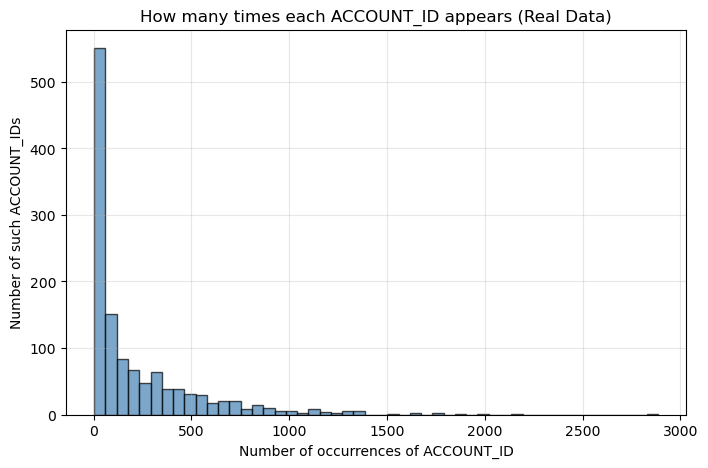

In [ ]:
# Сколько раз каждый ACCOUNT_ID встречается
freq = real_data['ACCOUNT_ID'].value_counts()
freq2 = synth_data['ACCOUNT_ID'].value_counts()
# Теперь построим гистограмму ЧАСТОТ (а не самих ID!)
plt.figure(figsize=(8, 5))
plt.hist(freq, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
plt.xlabel('Number of occurrences of ACCOUNT_ID')
plt.ylabel('Number of such ACCOUNT_IDs')
plt.title('How many times each ACCOUNT_ID appears (Real Data)')
plt.grid(True, alpha=0.3)
plt.show()


HIGH CARDINALITY ANALYSIS: ACCOUNT_ID


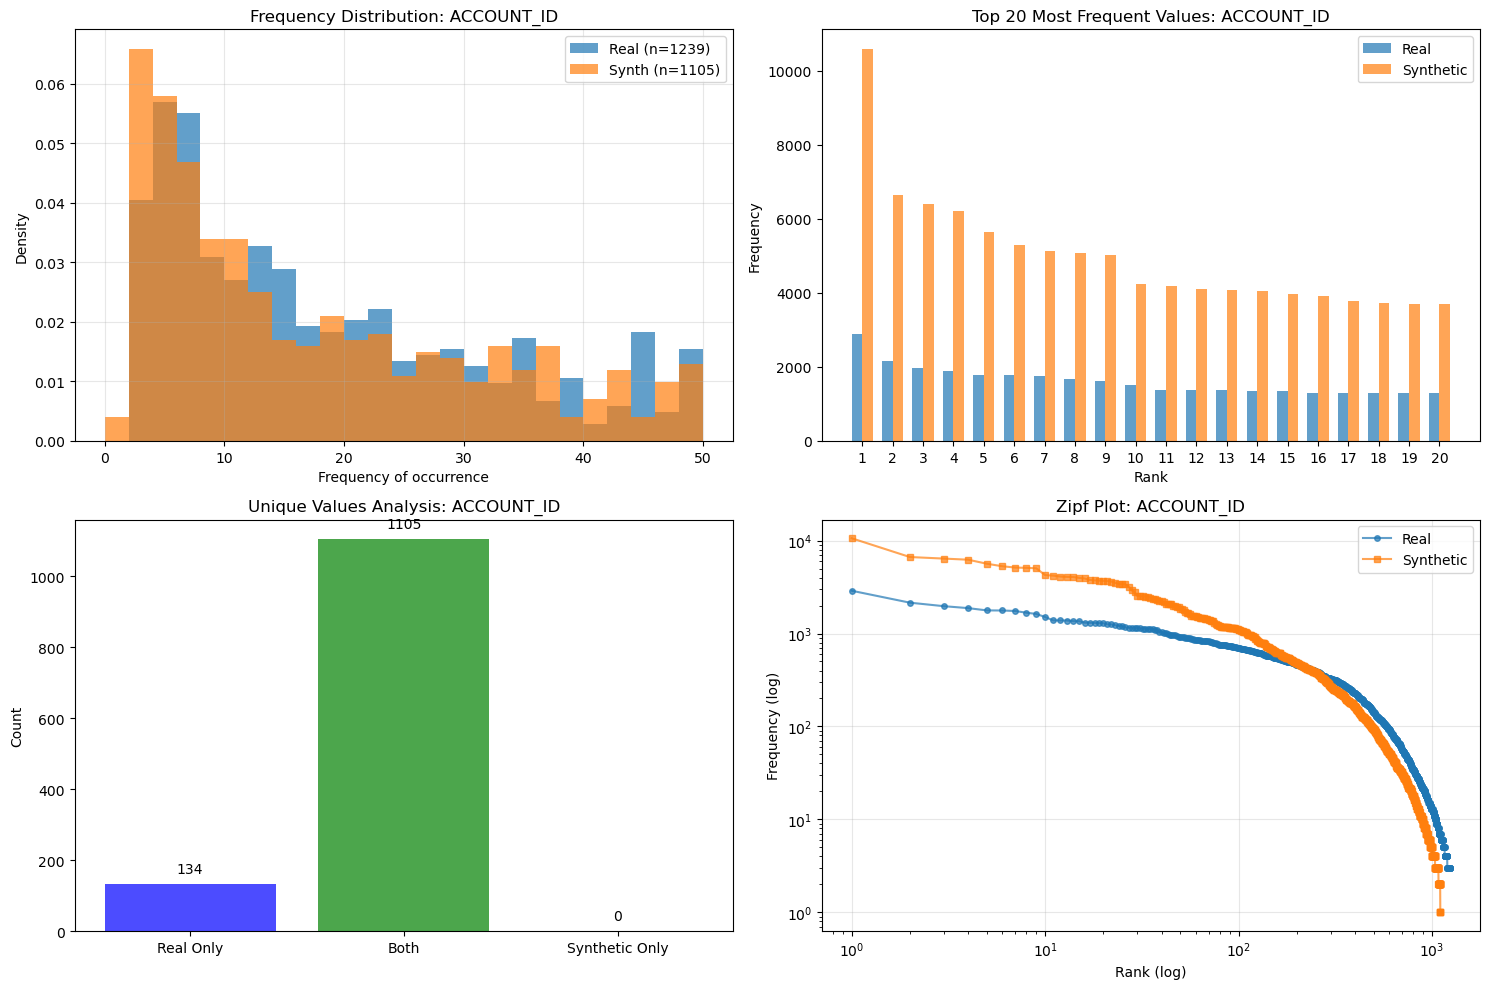

Unique values: Real=1,239, Synthetic=1,105
Overlap: 1,105 values (89.2% of real)
New in synthetic: 0 values (0.0% of synth)
Mean frequency: Real=222.16, Synthetic=361.99
⚠ WARNING: High overlap (89.2%) - possible data leakage!

HIGH CARDINALITY ANALYSIS: TERMINAL_CODE


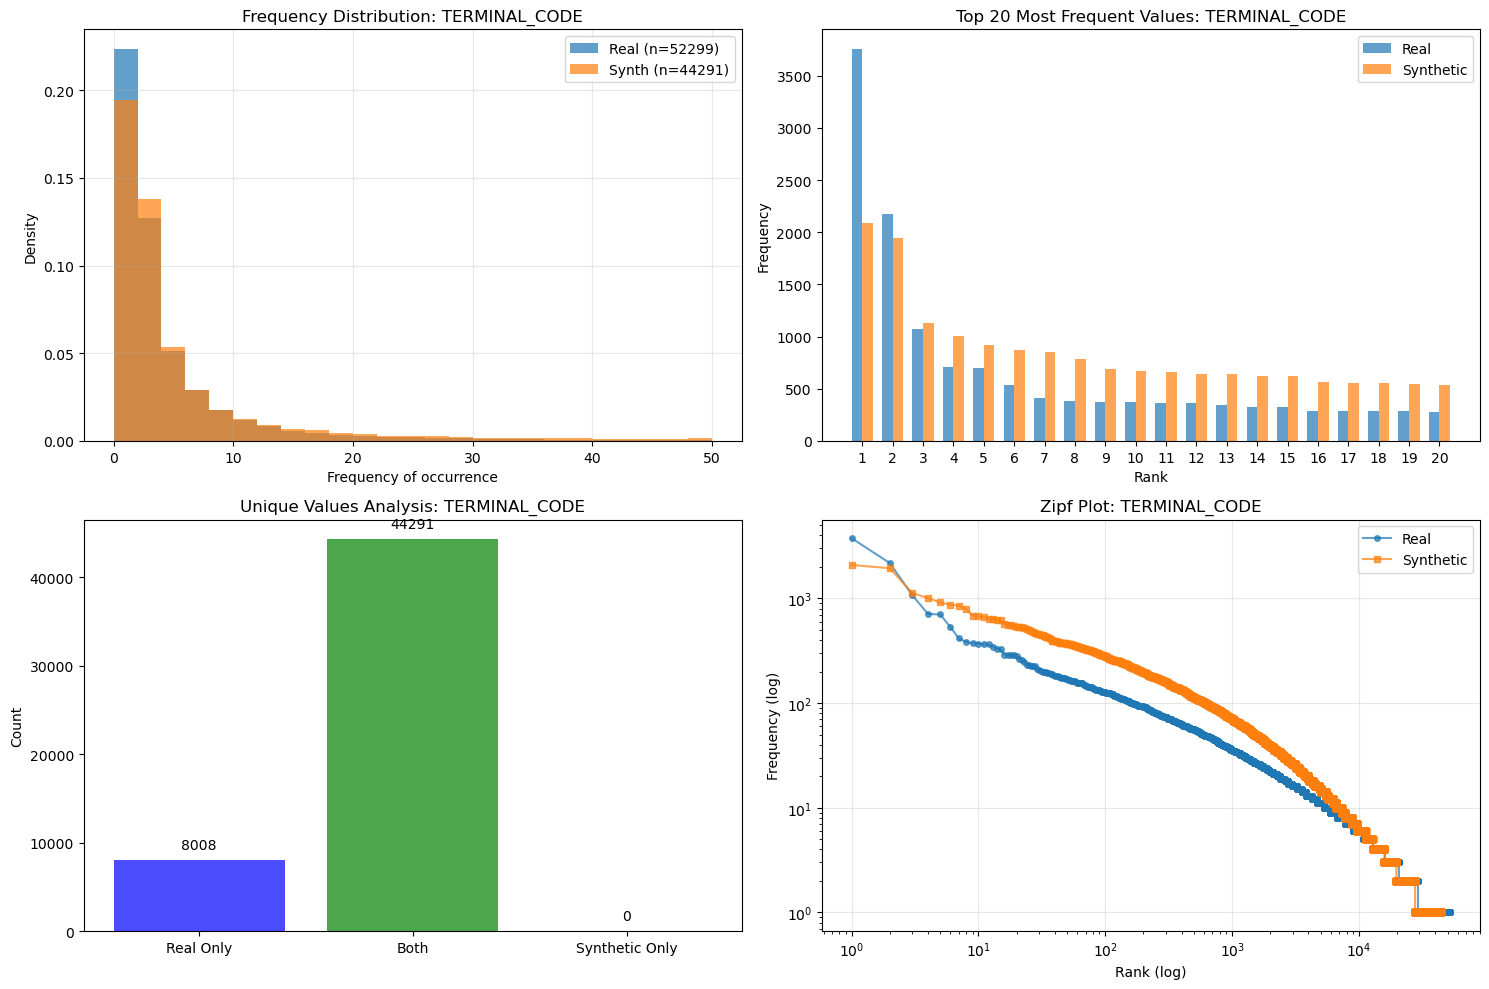

Unique values: Real=52,299, Synthetic=44,291
Overlap: 44,291 values (84.7% of real)
New in synthetic: 0 values (0.0% of synth)
Mean frequency: Real=5.26, Synthetic=9.03
⚠ WARNING: High overlap (84.7%) - possible data leakage!

HIGH CARDINALITY ANALYSIS: CARD


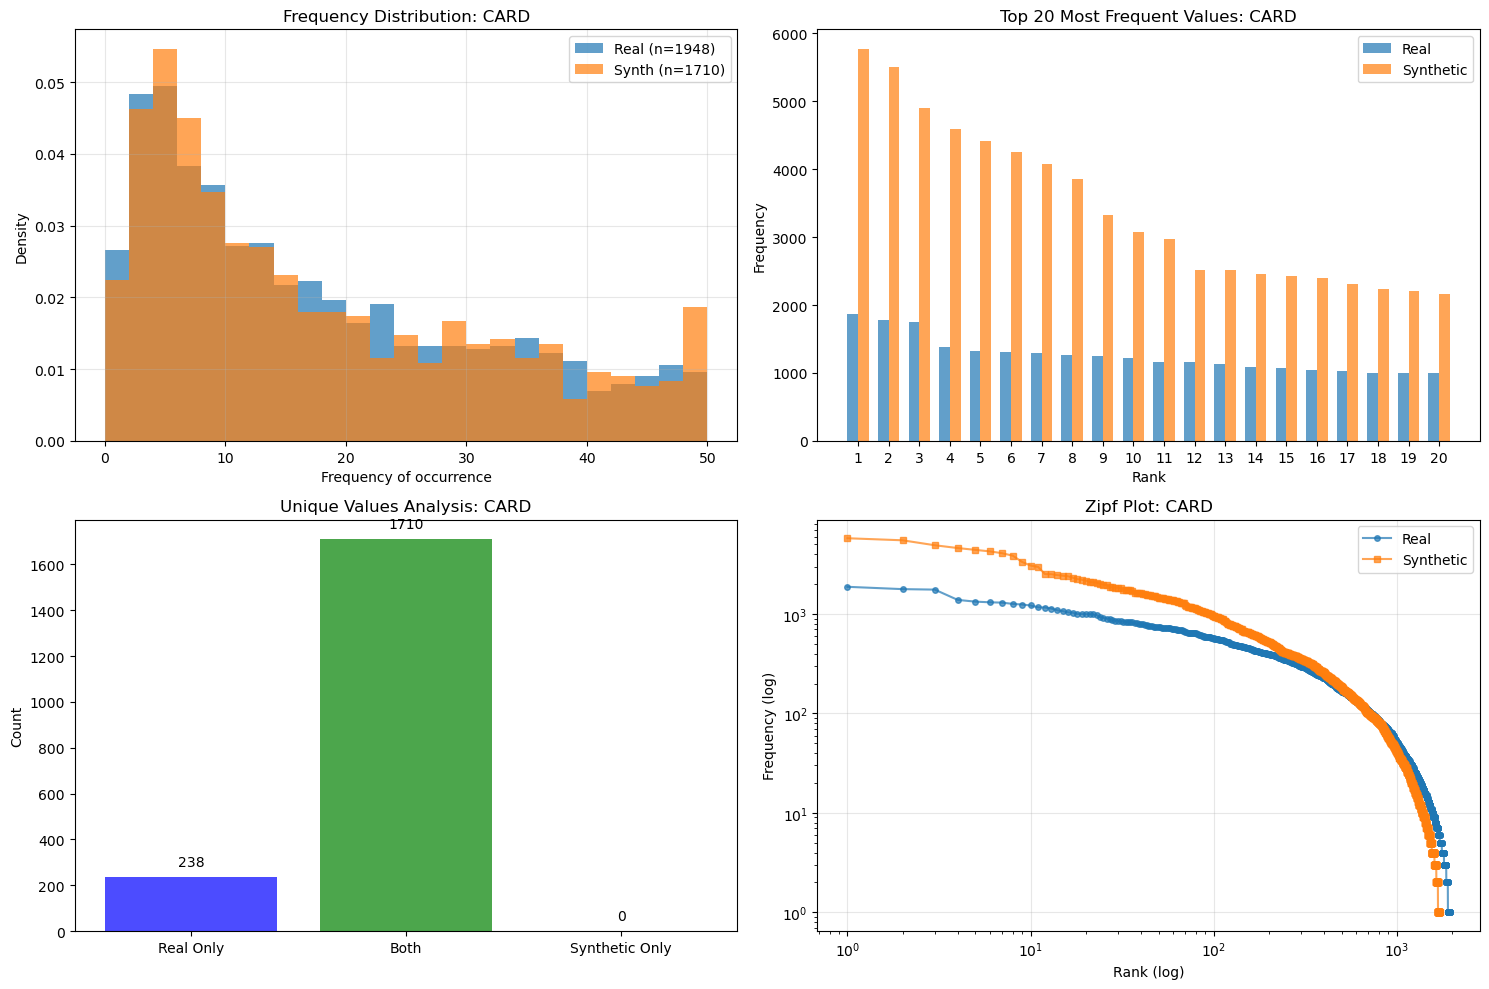

Unique values: Real=1,948, Synthetic=1,710
Overlap: 1,710 values (87.8% of real)
New in synthetic: 0 values (0.0% of synth)
Mean frequency: Real=141.30, Synthetic=233.92
⚠ WARNING: High overlap (87.8%) - possible data leakage!

HIGH CARDINALITY ANALYSIS: TRANS_DETAIL


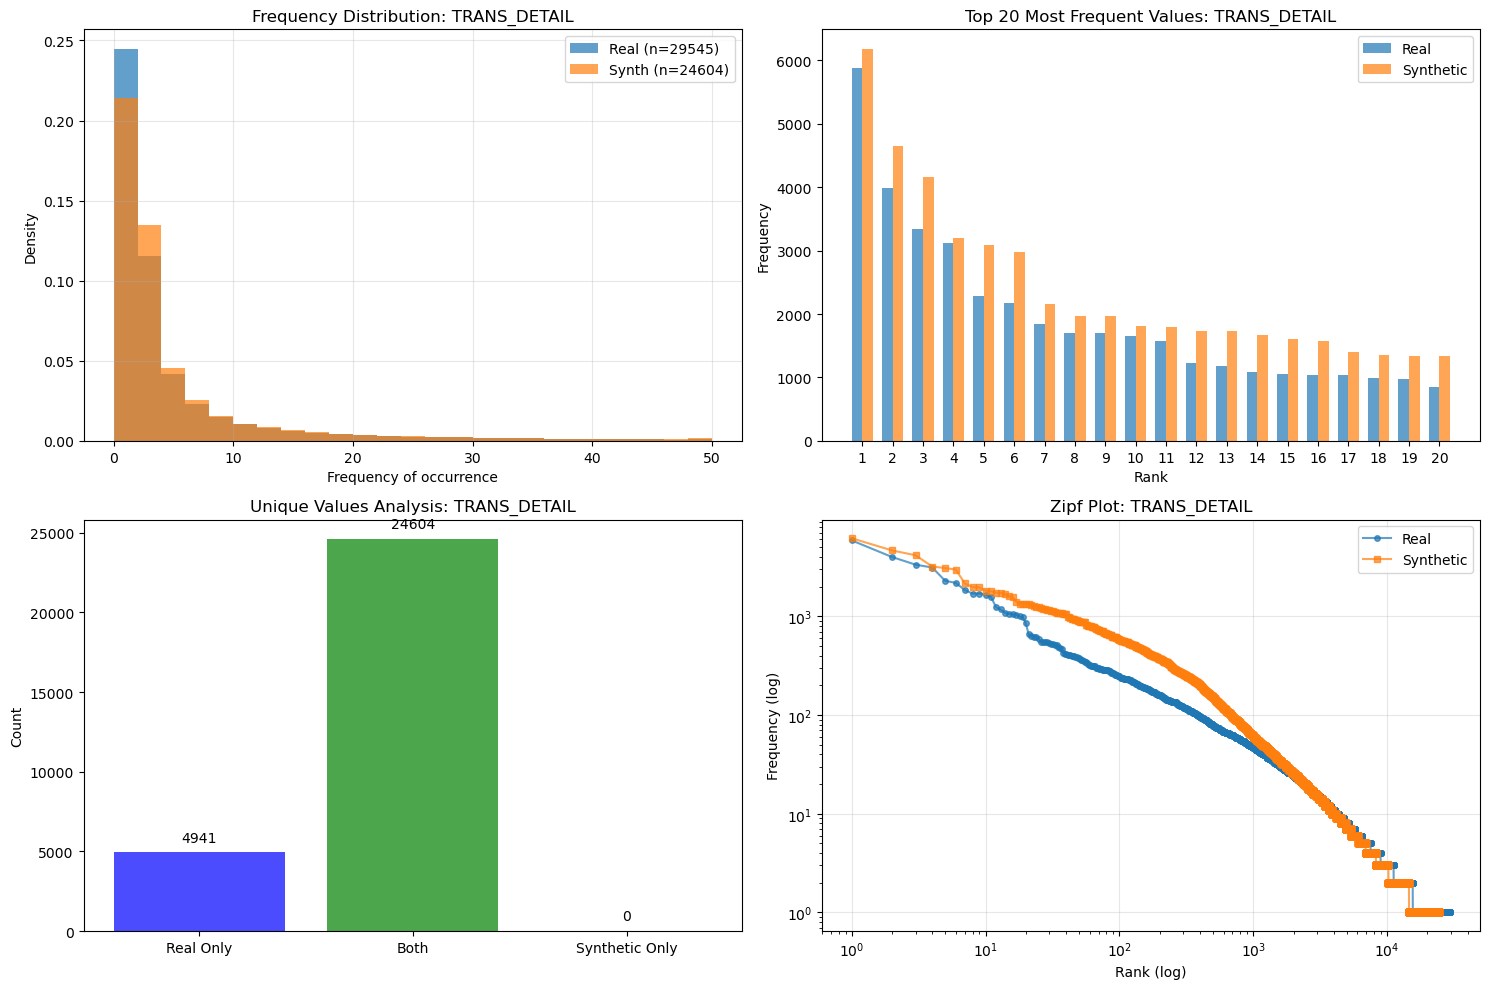

Unique values: Real=29,545, Synthetic=24,604
Overlap: 24,604 values (83.3% of real)
New in synthetic: 0 values (0.0% of synth)
Mean frequency: Real=9.32, Synthetic=16.26
⚠ WARNING: High overlap (83.3%) - possible data leakage!


In [60]:
categorical_results = test_categorical_fields(real_data, synth_data, CATEGORICAL_FIELDS)
